In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\matches_full.csv")
pd.set_option('display.max_columns', None)

In [3]:
data.sample(5)

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,captain,formation,opp formation,referee,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
307,25,2025-02-09,21:00,La Liga,Matchweek 23,Sun,Home,L,1.0,4.0,Barcelona,0.7,1.9,40.0,38592.0,Nemanja Gudelj,4-2-3-1,4-2-3-1,Alejandro Hernández,Match Report,NaN,8.0,4.0,17.3,0.0,0,0,2025,Sevilla
852,34,2024-04-15,21:00,La Liga,Matchweek 31,Mon,Away,W,1.0,0.0,Osasuna,0.2,1.9,35.0,19480.0,Giorgi Mamardashvili,4-4-2,4-4-2,José Luis Munuera,Match Report,NaN,4.0,3.0,17.9,0.0,0,0,2024,Valencia
10,13,2024-10-26,21:00,La Liga,Matchweek 11,Sat,Away,W,4.0,0.0,Real Madrid,2.6,1.5,57.0,78192.0,Raphinha,4-2-3-1,4-4-2,Jose Maria Sánchez,Match Report,NaN,15.0,7.0,21.7,0.0,0,0,2025,Barcelona
1439,15,2022-10-20,21:00,La Liga,Matchweek 10,Thu,Away,L,0.0,3.0,Barcelona,0.4,2.1,31.0,73261.0,Raúl Albiol,4-4-2,4-3-3,Carlos del Cerro,Match Report,NaN,5.0,1.0,22.0,0.0,0,0,2023,Villarreal
341,4,2024-09-18,19:00,La Liga,Matchweek 3,Wed,Away,L,1.0,2.0,Betis,0.6,2.6,35.0,48547.0,Djené,4-2-3-1,4-2-3-1,Juan Pulido,Match Report,NaN,15.0,5.0,21.7,0.0,0,0,2025,Getafe


### Data PreProcessing

#### Data Cleaning

In [4]:
data = data.drop(['Unnamed: 0'], axis=1)
data = data.drop(['comp'], axis=1)
data = data.drop(['captain'], axis=1)
data = data.drop(['referee'], axis=1)
data = data.drop(['match report'], axis=1)
data = data.drop(['notes'], axis=1)

In [5]:
# Standarized Value in 'formation' column
data['formation'].unique()

array(['4-2-3-1', '4-3-3', '4-1-4-1', '3-4-3', '5-3-2', '4-4-2', '5-4-1',
       '4-1-2-1-2◆', '4-4-1-1', '4-2-2-2', '4-5-1', '3-5-2', '3-5-1-1',
       '3-1-4-2', '3-4-3◆', '3-4-1-2', '4-1-3-2', '4-3-1-2', '3-2-4-1',
       '4-3-2-1', '4-2-4-0', '3-3-3-1'], dtype=object)

In [6]:
# Membersihkan simbol tidak diperlukan, misalnya ◆
data['formation'] = data['formation'].str.replace('◆', '', regex=False)

In [7]:
data['formation'] = data['formation'].replace('4-2-4-0', '4-2-4')

In [8]:
data['date'] = pd.to_datetime(data['date'])

In [9]:
data['time'] = pd.to_datetime(data['time'], format = '%H:%M').dt.time

In [10]:
data['opponent'] = data['opponent'].astype('category')

In [11]:
# change the data type to int
data['sh'] = data['sh'].astype(int)
data['sot'] = data['sot'].astype(int)
data['ga'] = data['ga'].astype(int)
data['gf'] = data['gf'].astype(int)
data['fk'] = data['fk'].astype(int)

In [12]:
data.sample(5)

,date,time,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team
2895,2021-02-13,21:00:00,Matchweek 23,Sat,Home,W,5,1,Alavés,2.4,0.7,73.0,NaN,4-3-3,4-4-2,17,9,16.1,1,0,0,2021,Barcelona
2836,2020-09-20,21:00:00,Matchweek 2,Sun,Away,D,0,0,Real Sociedad,0.9,0.6,68.0,NaN,4-2-3-1,4-4-2,16,4,20.1,0,0,0,2021,Real Madrid
4134,2019-09-29,16:00:00,Matchweek 7,Sun,Home,W,2,0,Mallorca,2.1,0.2,54.0,17135.0,4-4-2,4-2-3-1,10,5,22.9,0,1,1,2020,Alaves
3357,2021-03-21,14:00:00,Matchweek 28,Sun,Home,D,1,1,Elche,1.8,1.5,48.0,NaN,4-2-3-1,4-2-3-1,11,4,21.3,2,0,1,2021,Getafe
774,2024-03-17,18:30:00,Matchweek 29,Sun,Away,L,0,2,Rayo Vallecano,0.8,0.7,61.0,13264.0,4-2-3-1,4-2-3-1,11,1,14.8,0,0,0,2024,Real Betis


#### Check NaN Value & Handling Missing Value

In [13]:
data.isnull().sum()

date               0
time               0
round              0
day                0
venue              0
result             0
gf                 0
ga                 0
opponent           0
xg                 0
xga                0
poss               0
attendance       974
formation          0
opp formation      0
sh                 0
sot                0
dist               3
fk                 0
pk                 0
pkatt              0
season             0
team               0
dtype: int64

In [14]:
data['attendance'] = data.groupby(['team', 'venue', 'opponent'])['attendance'].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\ryana\AppData\Local\Temp\ipykernel_740\321960465.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data['attendance'] = data.groupby(['team', 'venue', 'opponent'])['attendance'].transform(
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ryana\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdi

In [15]:
# we still got the null value, then we will imputation with median techic
data['attendance'] = data['attendance'].fillna(data['attendance'].median())

In [16]:
# change the data type to int
data['attendance'] = data['attendance'].astype(int)

In [17]:
data['dist'] = data.groupby(['venue', 'team'])['dist'].transform(
    lambda x: x.fillna(x.mean())
)

In [18]:
data.isnull().sum()

date             0
time             0
round            0
day              0
venue            0
result           0
gf               0
ga               0
opponent         0
xg               0
xga              0
poss             0
attendance       0
formation        0
opp formation    0
sh               0
sot              0
dist             0
fk               0
pk               0
pkatt            0
season           0
team             0
dtype: int64

### Pre-Processing

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
data_model = data.copy()

In [ ]:
data_model = data_model.drop('time', axis=1)

In [ ]:
data.sample()

In [20]:
df_trial = data.copy()

In [21]:
result_map = {'W':2, 'D':1, 'L':0}
df_trial['target_pred'] = df_trial['result'].map(result_map)

In [22]:
# Home/Away flag
df_trial['is_home'] = df_trial['venue'].map({'Home': 1, 'Away': 0})

In [23]:
df_trial1 = df_trial.copy()

In [24]:
df_trial1.sample()

,date,time,round,day,venue,result,gf,ga,opponent,xg,xga,poss,attendance,formation,opp formation,sh,sot,dist,fk,pk,pkatt,season,team,target_pred,is_home
973,2024-05-26,14:00:00,Matchweek 38,Sun,Home,L,1,2,Mallorca,0.9,1.4,50.0,9545,4-1-4-1,4-1-4-1,16,6,20.7,2,0,0,2024,Getafe,0,1


In [25]:
# Hapus kolom yang tidak relevan
drop_cols = ['date', 'time', 'round', 'day', 'opponent', 'venue', 'result', 'formation', 'opp formation', 'dist', 'season', 'team']  # karena redundant/target leak
df_trial1 = df_trial1.drop(columns=drop_cols)

In [26]:
df_trial1.isnull().sum()

gf             0
ga             0
xg             0
xga            0
poss           0
attendance     0
sh             0
sot            0
fk             0
pk             0
pkatt          0
target_pred    0
is_home        0
dtype: int64

In [ ]:
from seaborn import swarmplot

data_to_plot = pd.melt(df_trial1[['gf', 'ga', 'poss', 'target_pred']],
                       id_vars='target_pred',
                       var_name='features',
                       value_name='value')

swarmplot(data=data_to_plot, x='features', y='value', hue='target_pred');

In [27]:
df_trial1['target_pred'].value_counts()

target_pred
2    1566
0    1566
1    1186
Name: count, dtype: int64

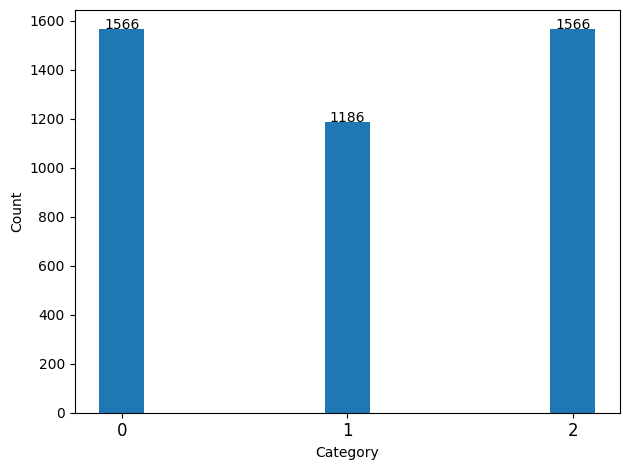

In [28]:
fig, ax = plt.subplots()

x = [0, 1, 2]
y = [1566, 1186, 1566]

ax.bar(x, y, width=0.2)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.set_xticks([0,1,2])
ax.set_xticklabels([0,1,2], fontsize=12)

for index, value in enumerate(y):
    plt.text(x=int(index), y=value+1, s=str(value), ha='center')
    
plt.tight_layout()

#### Add Feature

In [38]:
#create feature that indicate attacking power vs defensive power
df_trial1['xg_diff'] = df_trial1['xg'] - df_trial1['xga']

In [39]:
# shooting Accuracy
df_trial1['sh_accuracy'] = df_trial1.apply(
    lambda row: row['sot'] / row['sh'] if row['sh'] != 0 else 0,
    axis=1
)

In [40]:
df_trial1['sh_per_poss'] = df_trial1.apply(
    lambda row: row['sh'] / row['poss'] if row['poss'] != 0 else 0,
    axis=1
)

In [41]:
df_trial1['sot_per_xg'] = df_trial1.apply(
    lambda row: row['sot'] / row['xg'] if row['xg'] != 0 else 0,
    axis=1
)

### Train/Test Split

In [42]:
from sklearn.model_selection import train_test_split

X = df_trial1.drop(['target_pred', 'ga', 'gf'], axis=1)
y = df_trial1['target_pred']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                   y,
                                                   test_size=0.3,
                                                   shuffle=True,
                                                   stratify=y,
                                                   random_state=42)

In [43]:
print(X_train.shape)
print(X_test.shape)

(3022, 14)
(1296, 14)


### Baseline model: Gradient Boosting Classifier

In [44]:
X_train.sample()

,xg,xga,poss,attendance,sh,sot,fk,pk,pkatt,is_home,xg_diff,sh_accuracy,sh_per_poss,sot_per_xg
2147,0.7,1.3,57.0,43398,9,3,1,0,0,0,-0.6,0.333333,0.157895,4.285714


In [45]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

# Initialize classifier
gbc = GradientBoostingClassifier(max_depth=5, random_state=42)

# Train classifier using all features
gbc.fit(X_train, y_train)

# Make predictions
preds = gbc.predict(X_test)

# Evaluate the model using the F1-score
f1_score_all = round(f1_score(y_test, preds, average='weighted'), 3)

print(f1_score_all)

0.584


#### Feature Selection

#### Variance threshold

In [46]:
X_train_v1, X_test_v1, y_tain_v1, y_test_v1 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [47]:
# Calculate the variance of each feature
X_train_v1.var(axis=0)

xg             5.938582e-01
xga            5.819112e-01
poss           1.303321e+02
attendance     3.098361e+08
sh             2.318579e+01
sot            5.286747e+00
fk             4.777004e-01
pk             1.265201e-01
pkatt          1.652515e-01
is_home        2.500828e-01
xg_diff        1.362134e+00
sh_accuracy    2.772985e-02
sh_per_poss    8.044803e-03
sot_per_xg     7.113731e+00
dtype: float64

In [48]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_X_train_v1 = scaler.fit_transform(X_train_v1)

C:\Users\ryana\AppData\Local\Temp\ipykernel_740\2308019592.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


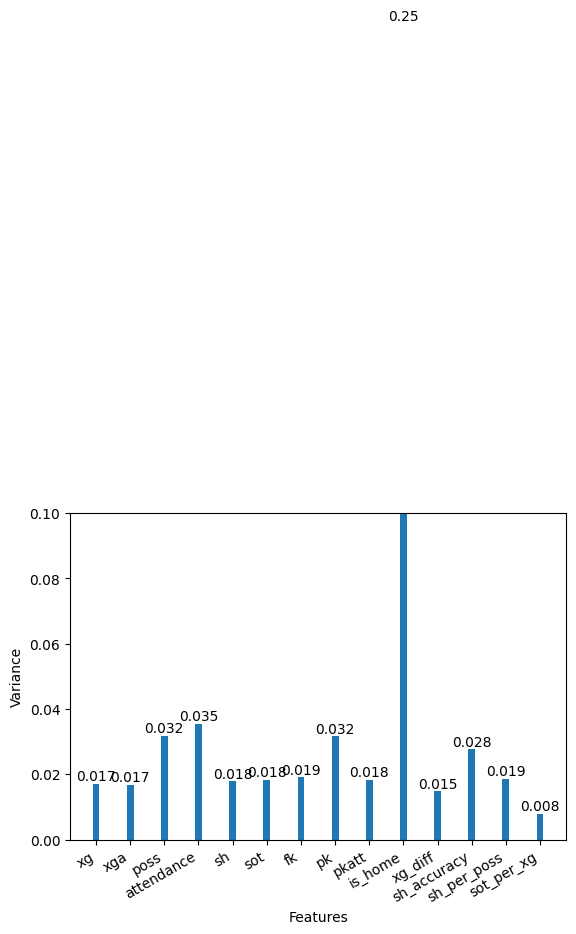

In [49]:
fig, ax = plt.subplots()

x = X.columns
y = scaled_X_train_v1.var(axis=0)

ax.bar(x, y, width=0.2)
ax.set_xlabel('Features')
ax.set_ylabel('Variance')
ax.set_ylim(0, 0.1)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.001, s=str(round(value, 3)), ha='center')
    
fig.autofmt_xdate()
plt.tight_layout()

In [50]:
sel_X_train_v1 = X_train_v1.drop(['sot_per_xg'], axis=1)
sel_X_test_v1 = X_test_v1.drop(['sot_per_xg'], axis=1)

gbc.fit(sel_X_train_v1, y_train)

var_preds = gbc.predict(sel_X_test_v1)

f1_score_var = round(f1_score(y_test_v1, var_preds, average='weighted'), 3)

print(f1_score_var)

0.586


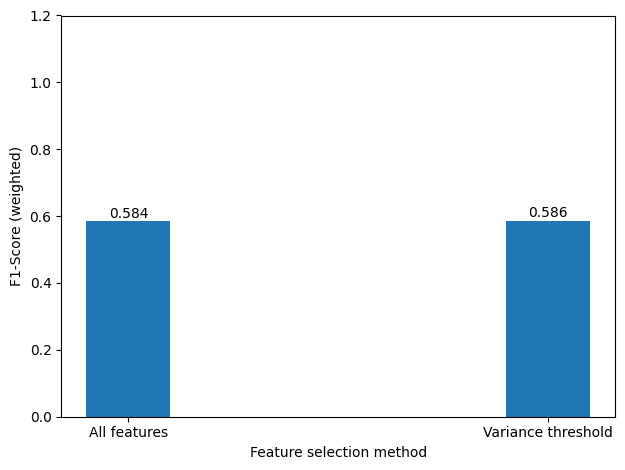

In [51]:
fig, ax = plt.subplots()

x = ['All features', 'Variance threshold']
y = [f1_score_all, f1_score_var]

ax.bar(x, y, width=0.2)
ax.set_xlabel('Feature selection method')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.01, s=str(round(value,3)), ha='center')
    
plt.tight_layout()

#### K-Best Features

In [52]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [53]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

f1_score_list = []

for k in range(1, 14):
    selector = SelectKBest(mutual_info_classif, k=k)
    selector.fit(X_train_v2, y_train_v2)
    
    sel_X_train_v2 = selector.transform(X_train_v2)
    sel_X_test_v2 = selector.transform(X_test_v2)
    
    gbc.fit(sel_X_train_v2, y_train_v2)
    kbest_preds = gbc.predict(sel_X_test_v2)
    
    f1_score_kbest = round(f1_score(y_test_v2, kbest_preds, average='weighted'), 3)
    
    f1_score_list.append(f1_score_kbest)

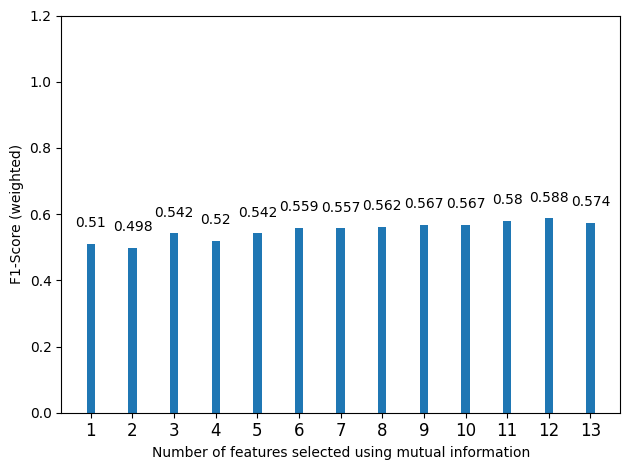

In [54]:
fig, ax = plt.subplots()

x = np.arange(1, 14)
y = f1_score_list

ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of features selected using mutual information')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1, 14))
ax.set_xticklabels(np.arange(1, 14), fontsize=12)

for i, v in enumerate(y):
    plt.text(x=i+1, y=v+0.05, s=str(v), ha='center')
    
plt.tight_layout()

In [57]:
selector = SelectKBest(mutual_info_classif, k=10)
selector.fit(X_train_v2, y_train_v2)

selected_feature_mask = selector.get_support()

selected_features = X_train_v2.columns[selected_feature_mask]

selected_features

Index(['xg', 'xga', 'sh', 'sot', 'fk', 'pk', 'is_home', 'xg_diff',
       'sh_accuracy', 'sot_per_xg'],
      dtype='object')

### Machine Learning

In [74]:
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns

In [59]:
y_test.sample(3)

2204    2
1629    0
572     1
Name: target_pred, dtype: int64

In [70]:
cols = [
    'xg', 'xga', 'sh', 'sot', 'fk', 'pk', 'is_home', 'xg_diff',
    'sh_accuracy', 'sot_per_xg'
]

train_data = df_trial1[cols]
test_data = df_trial1['target_pred']

In [71]:
# Buat model dan latih
model = RandomForestRegressor()
model.fit(train_data, test_data)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
feature_importance = model.feature_importances_

# Tampilkan dalam DataFrame
importance_df = pd.DataFrame({
    'Fitur': train_data.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

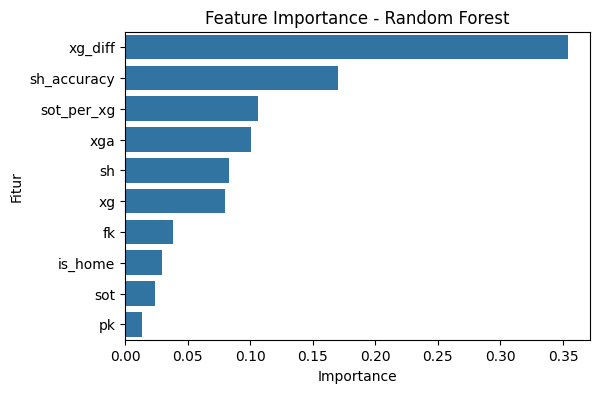

In [75]:
# Visualisasikan
plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Fitur', data=importance_df)
plt.title('Feature Importance - Random Forest')
plt.show()

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.69      0.64       470
           1       0.35      0.24      0.28       356
           2       0.65      0.71      0.68       470

    accuracy                           0.57      1296
   macro avg       0.53      0.55      0.53      1296
weighted avg       0.55      0.57      0.56      1296

[[325  84  61]
 [157  84 115]
 [ 66  71 333]]
